In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test)= fashion_mnist.load_data()
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


<function matplotlib.pyplot.show(close=None, block=None)>

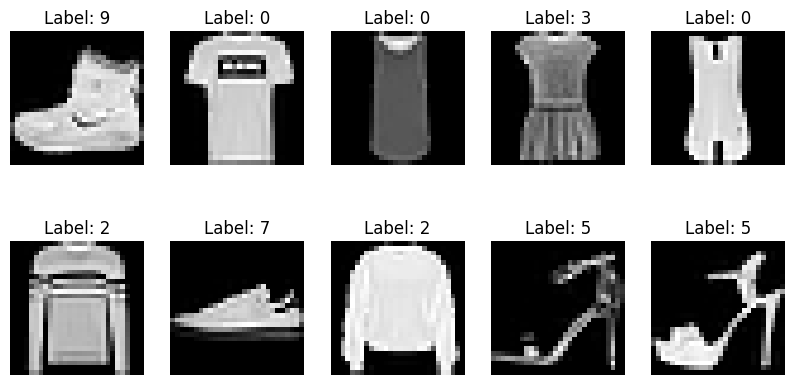

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
y_train =to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = Sequential()

#First Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
#First Pooling Layer
model.add(MaxPooling2D((2,2)))

#Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
#Second Pooling Layer
model.add(MaxPooling2D((2,2)))

#Flatten Layer
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128, activation='relu'))

#Dropout Layer
model.add(Dropout(0.5))

#Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics =['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs =10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7788 - loss: 0.6160 - val_accuracy: 0.8552 - val_loss: 0.4003
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8519 - loss: 0.4150 - val_accuracy: 0.8804 - val_loss: 0.3246
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8684 - loss: 0.3606 - val_accuracy: 0.8882 - val_loss: 0.3016
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8802 - loss: 0.3269 - val_accuracy: 0.8964 - val_loss: 0.2825
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8888 - loss: 0.3046 - val_accuracy: 0.8930 - val_loss: 0.2914
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8957 - loss: 0.2813 - val_accuracy: 0.9043 - val_loss: 0.2599
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9030 - loss: 0.2636 - val_accuracy: 0.9004 - val_loss: 0.2732
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9083 - loss: 0.2487 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9046 - loss: 0.2696
Test Loss: 0.2695700228214264
Test Accuracy: 0.9046000242233276


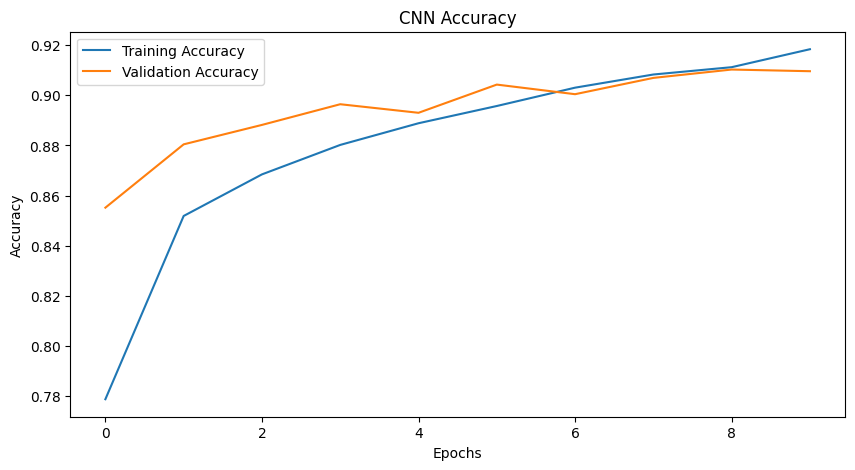

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

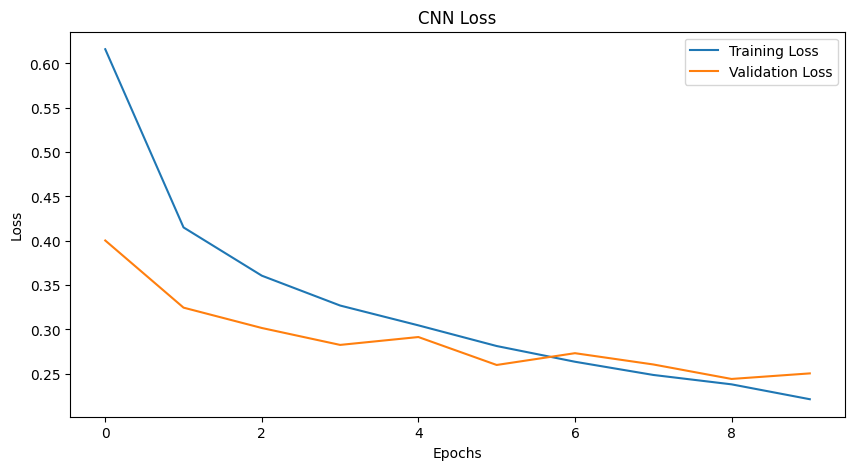

In [ ]:
#Loss Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


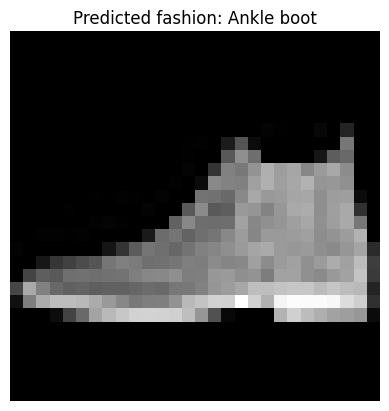

In [ ]:
sample = X_test[0]
prediction = model.predict(sample.reshape(1,28,28,1))
predicted_label = np.argmax(prediction)
#Define fashion MNIST CLASS NAMES(IF NOT ALREADY DEFINED IN GLOBAL SCOPE)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
predicted_fashion_name = class_names[predicted_label]
plt.imshow(sample.reshape(28,28), cmap='gray')
plt.title(f"Predicted fashion: {predicted_fashion_name}")
plt.axis('off')
plt.show()

Saving download.jpg to download (1).jpg


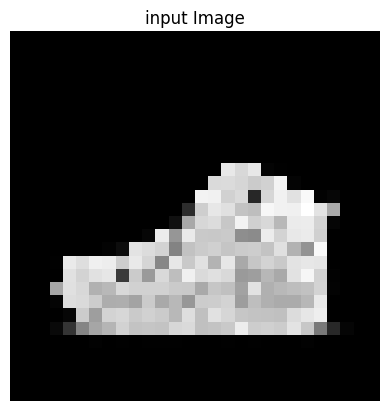

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted_fashion_name: Ankle boot
Predicted Probability: 77.83368 %


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
#Define fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#Upload an image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img =cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
#Resize the image
img = cv2.resize(img, (28,28))

#invert colors
img = 255 - img
#Normalize the image
img = img/255.0

#Display Image
plt.imshow(img, cmap='gray')
plt.title("input Image")
plt.axis('off')
plt.show()

#Reshape for CNN
img = img.reshape(1,28,28,1)

#Predict the image
prediction = model.predict(img)
predicted_label = np.argmax(prediction)
predicted_class = class_names[predicted_label]
print(f"Predicted_fashion_name: {predicted_fashion_name}")

#Print the confidence score
print("Predicted Probability:",np.max(prediction)*100,"%")